# 05 Graph interference design frontier

This notebook uses MovieLens 32M as a realistic user-item graph substrate. We calibrate a graph-spillover simulation from the ratings distribution and compare user randomization, cluster randomization, switchback, budget split, two-stage saturation, and mixed randomization under known ground truth.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT.name != "online_experiment_designs_under_interference" and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "code" / "src"))

from config import ProjectPaths
from data_cases import load_movielens_sample, movielens_calibration, run_movielens_graph_case
from designs import design_recommendations, pareto_frontier, uncertainty_shortlist
from figures import plot_bias_variance_frontier, plot_design_risk
from progress import ProgressLogger
from tables import write_table

paths = ProjectPaths.from_anywhere(PROJECT_ROOT)
paths.ensure()
progress = ProgressLogger("05-graph")

In [2]:
progress.log("Loading a MovieLens ratings sample from the zip archive.")
movielens_path = paths.data_dir / "movieLens" / "ml-32m.zip"
sample = load_movielens_sample(movielens_path, nrows=500_000)
calibration = movielens_calibration(sample)
write_table(pd.DataFrame([calibration]), paths.table_dir / "05_movielens_calibration.csv")
calibration

[04:26:14] 05-graph: Loading a MovieLens ratings sample from the zip archive.
[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/tables/05_movielens_calibration.csv


{'n_rows': 500000.0,
 'n_users': 3238.0,
 'n_items': 21509.0,
 'mean_rating': 3.552823,
 'rating_sd': 1.0644287184626284}

In [3]:
progress.log("Running graph-spillover design comparison calibrated to MovieLens.")
summary = run_movielens_graph_case(sample, n_reps=120)
ranked = design_recommendations(summary)
write_table(ranked, paths.table_dir / "05_movielens_graph_design_scores.csv")
frontier = pareto_frontier(ranked)
shortlist = uncertainty_shortlist(ranked)
write_table(frontier, paths.table_dir / "05_movielens_graph_pareto_frontier.csv")
write_table(shortlist, paths.table_dir / "05_movielens_graph_uncertainty_shortlist.csv")
ranked[["design", "design_risk", "exposure_distance", "assignment_unit_variance", "planning_mde", "contamination_risk", "operational_cost", "estimand_mismatch"]]

[04:26:14] 05-graph: Running graph-spillover design comparison calibrated to MovieLens.
[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/tables/05_movielens_graph_design_scores.csv
[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/tables/05_movielens_graph_pareto_frontier.csv
[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/tables/05_movielens_graph_uncertainty_shortlist.csv


,design,design_risk,exposure_distance,assignment_unit_variance,planning_mde,contamination_risk,operational_cost,estimand_mismatch
0,cluster_randomization,1.975527,0.503914,0.020471,0.047872,0.502332,0.35,0.503914
1,budget_split,2.144829,0.516664,0.009678,0.046560,0.495630,0.70,0.516664
2,two_stage_saturation,2.232464,0.495561,0.082182,0.030338,0.500324,0.80,0.495561
3,mixed_randomization,2.357254,0.527000,0.086037,0.031038,0.494611,0.90,0.527000
4,user_randomization,2.395802,0.509728,0.379219,0.054869,0.242113,0.10,0.509728
5,switchback,2.506736,0.750000,0.013155,0.143273,0.000000,0.45,0.750000


[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/figures/05_movielens_graph_design_risk.png


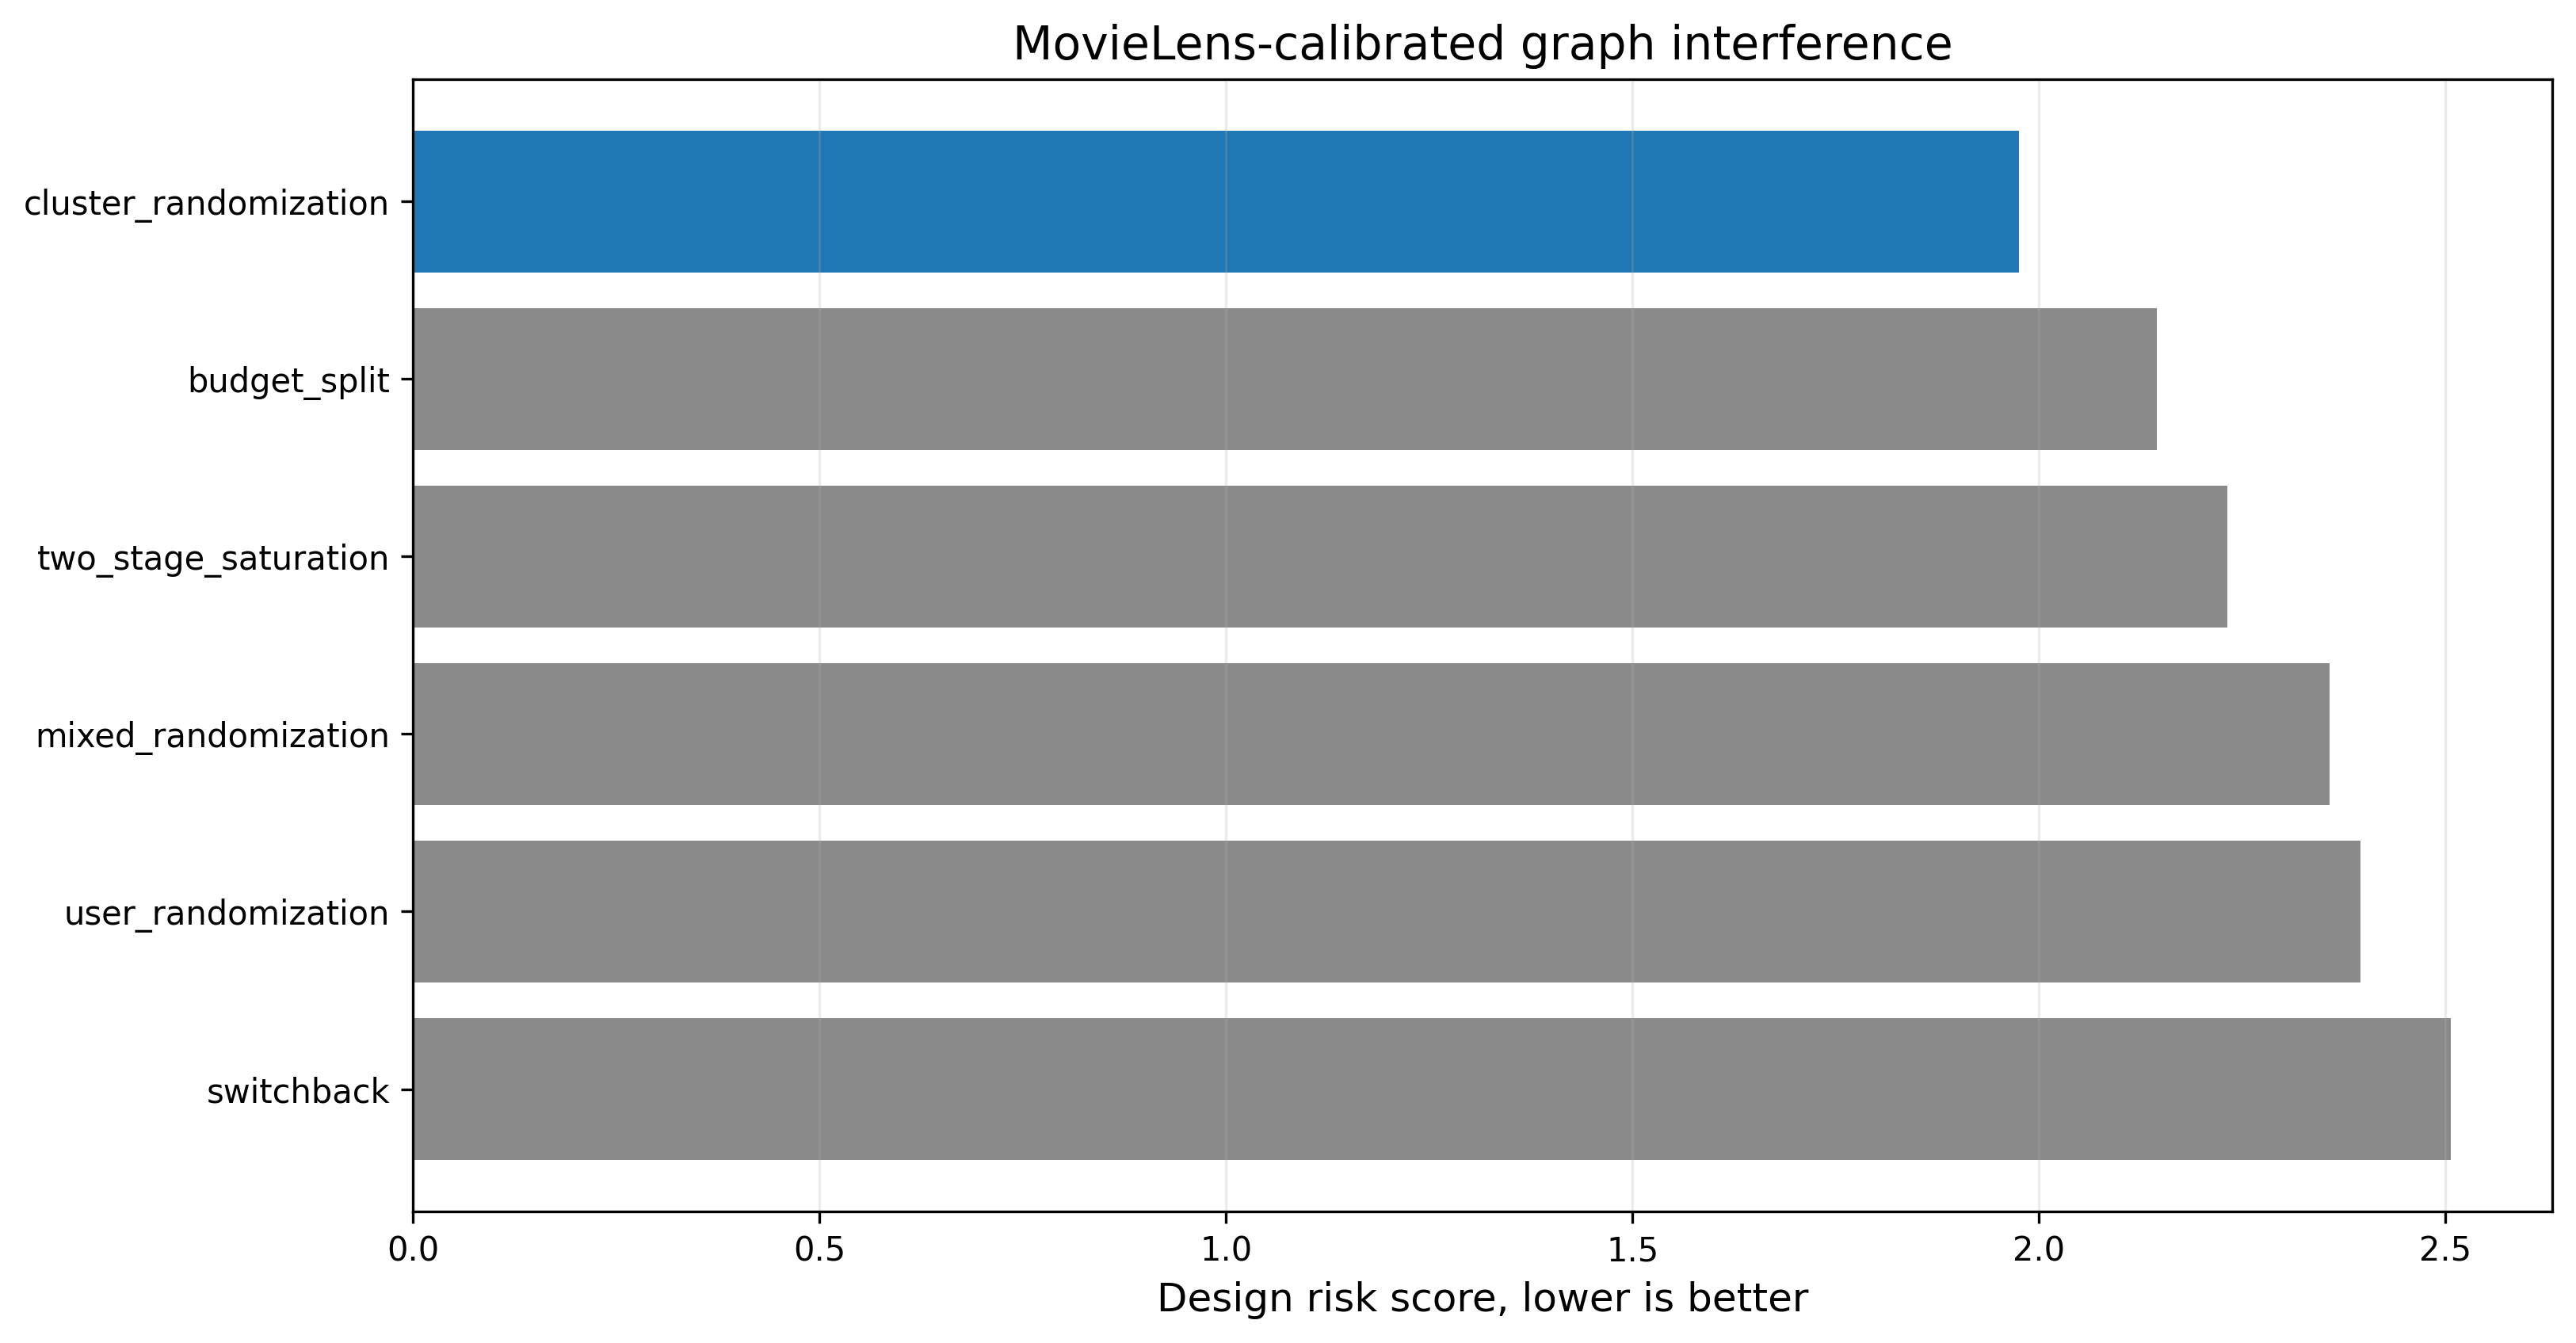

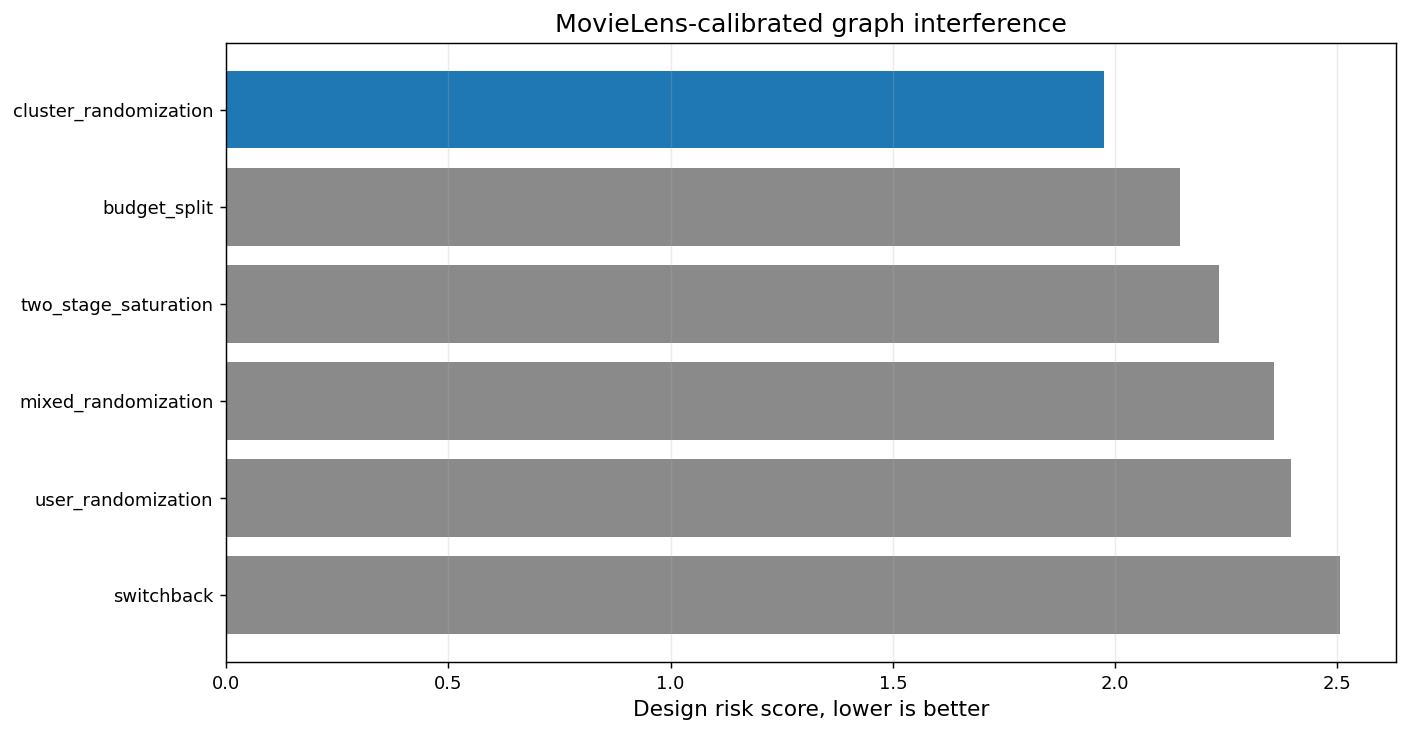

In [4]:
fig_path = paths.figure_dir / "05_movielens_graph_design_risk.png"
plot_design_risk(ranked, "MovieLens-calibrated graph interference", fig_path)
display(Image(filename=str(fig_path)))

[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/figures/05_movielens_bias_variance_frontier.png


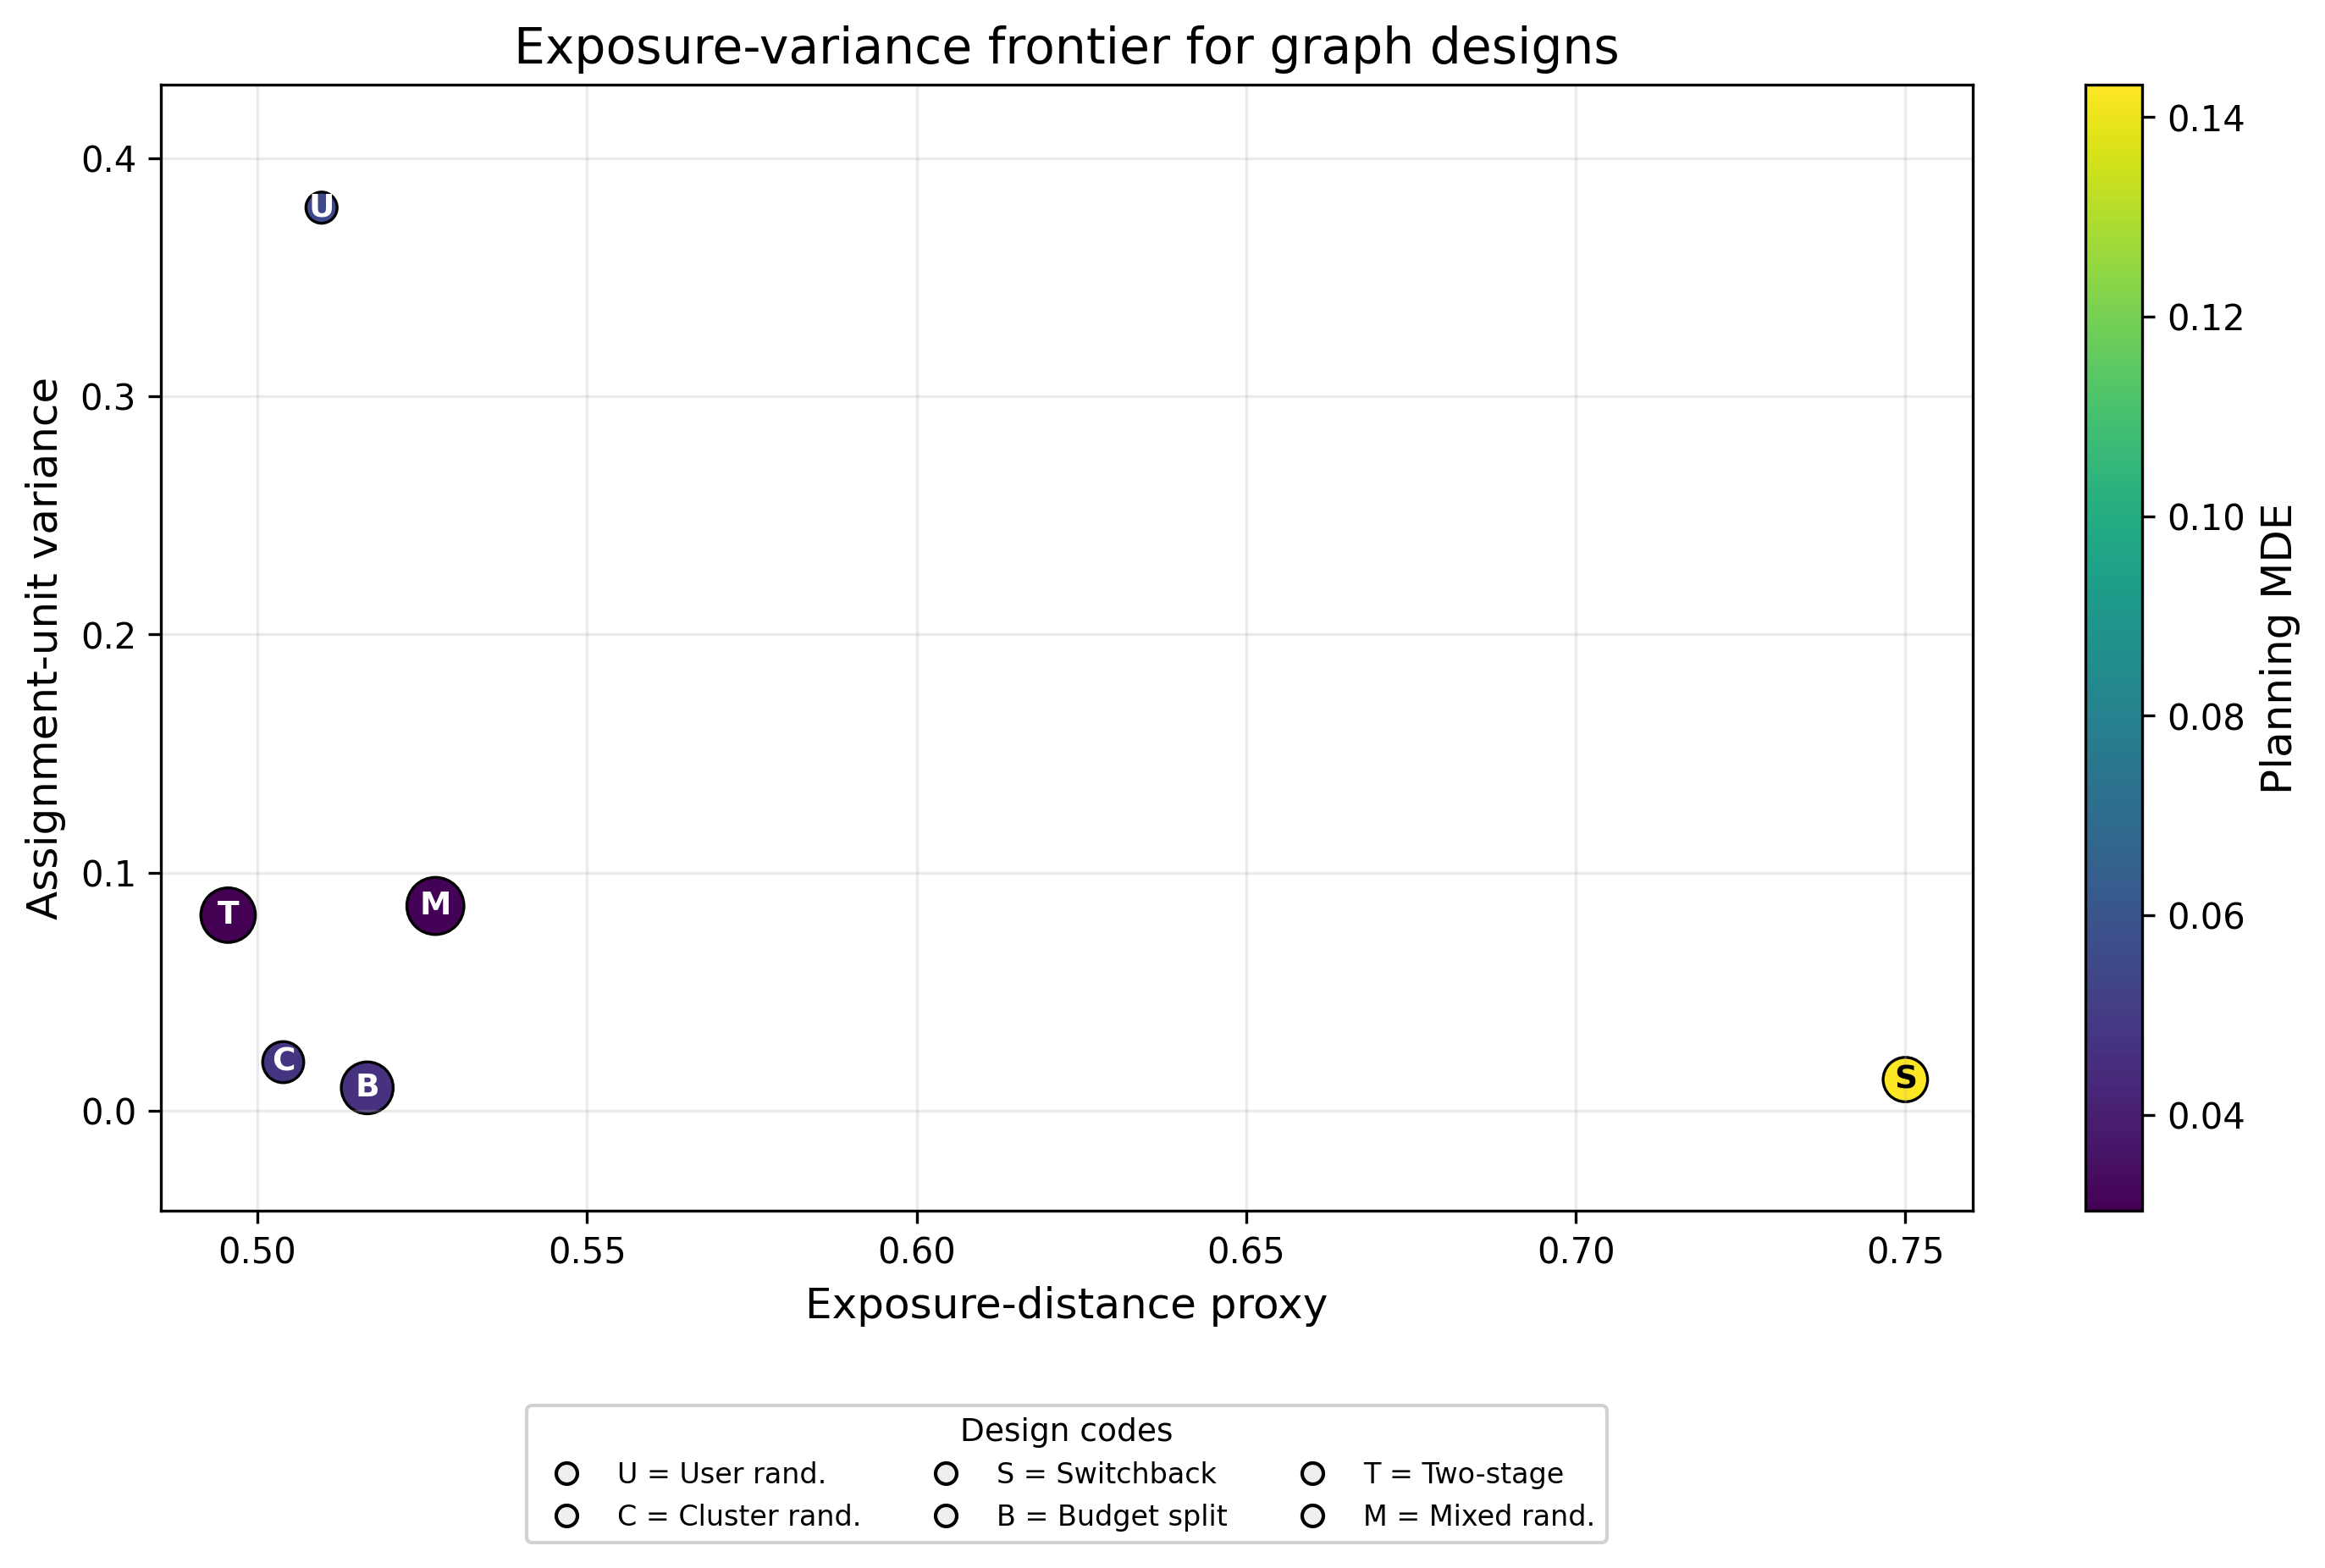

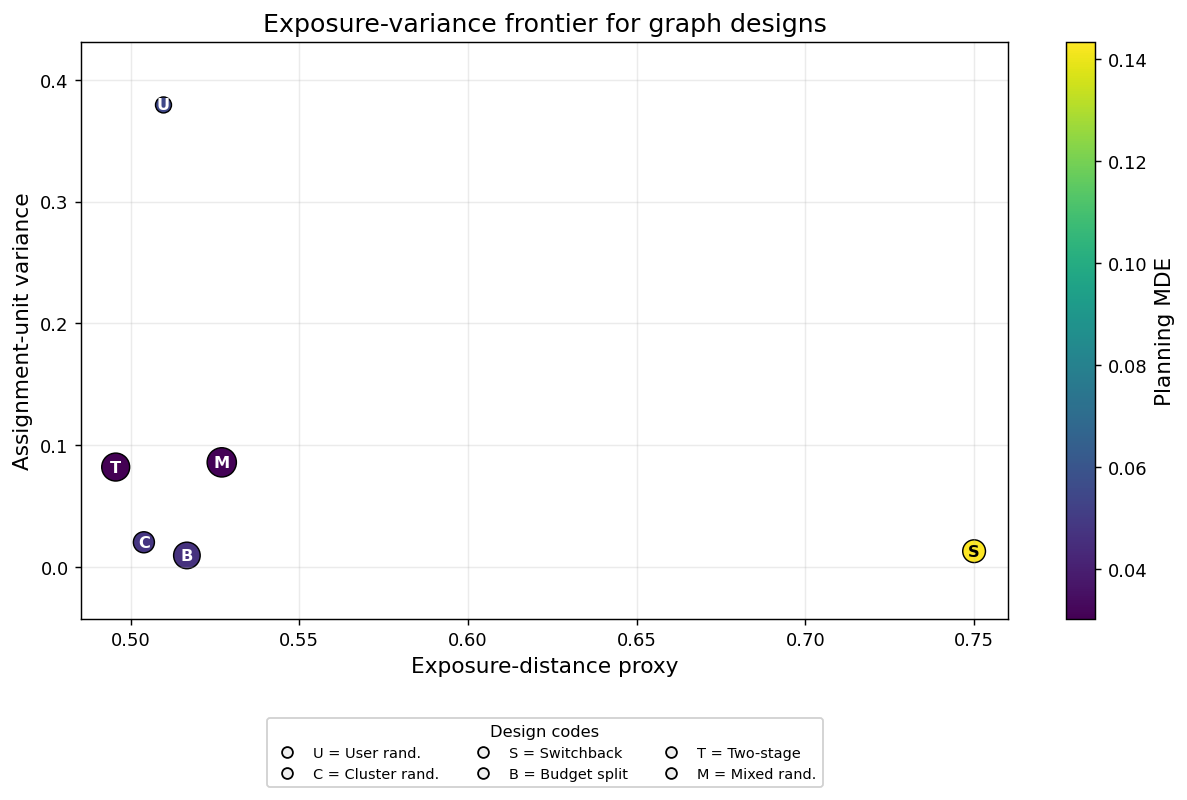

In [5]:
fig_path = paths.figure_dir / "05_movielens_bias_variance_frontier.png"
plot_bias_variance_frontier(ranked, "Exposure-variance frontier for graph designs", fig_path)
display(Image(filename=str(fig_path)))